# V4.3 Misclassification CSV Export

This notebook rebuilds the exact V4.3 held-out test split and exports misclassified sequences to CSV files for downstream analysis.

In [1]:
import gc
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split

print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

PyTorch: 2.9.0
NumPy: 1.26.4
Pandas: 2.3.3


In [2]:
# Paths and parameters copied from the V4.3 training notebook
FASTA_PATH = Path("../../../data/vgp/all_vgp_tes.fa")
LABEL_PATH = Path("../../../data/vgp/20260120_features_sf")
RESULTS_PATH = Path("./results_v4.3.pt")
OUT_DIR = Path(".")

KEEP_CLASSES = ("DNA", "LTR", "LINE")
EXCLUDE_GENOMES = {"mOrnAna", "bTaeGut", "rAllMis"}
MIN_CLASS_COUNT = 100
MAX_PER_SF = 3000
TEST_SIZE = 0.2
RANDOM_STATE = 42

print(f"FASTA exists: {FASTA_PATH.exists()} -> {FASTA_PATH}")
print(f"Labels exist: {LABEL_PATH.exists()} -> {LABEL_PATH}")
print(f"Results exist: {RESULTS_PATH.exists()} -> {RESULTS_PATH}")

FASTA exists: True -> ../../../data/vgp/all_vgp_tes.fa
Labels exist: True -> ../../../data/vgp/20260120_features_sf
Results exist: True -> results_v4.3.pt


In [3]:
def _extract_genome_id(header: str) -> str:
    name_part = header.split('#')[0]
    return name_part.rsplit('-', 1)[-1]


def read_fasta(path: Path):
    headers, sequences = [], []
    h, buf = None, []
    with path.open("r") as f:
        for line in f:
            if not line:
                continue
            if line[0] == '>':
                if h is not None:
                    sequences.append(''.join(buf).upper())
                    buf = []
                h = line[1:].strip()
                headers.append(h)
            else:
                buf.append(line.strip())
        if h is not None:
            sequences.append(''.join(buf).upper())
    return headers, sequences


def load_multiclass_labels(label_path: Path, keep_classes=("DNA", "LTR", "LINE")):
    class_to_id = {c: i for i, c in enumerate(keep_classes)}
    label_dict, class_dict = {}, {}

    with label_path.open("r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            header = parts[0].lstrip('>')
            tag = parts[1]
            top_class = tag.split('/')[0]
            if top_class in class_to_id:
                label_dict[header] = tag
                class_dict[header] = class_to_id[top_class]

    return label_dict, class_dict


def rebuild_v43_test_split(
    fasta_path: Path,
    label_path: Path,
    keep_classes=("DNA", "LTR", "LINE"),
    exclude_genomes=None,
    min_class_count=100,
    max_per_sf=3000,
    test_size=0.2,
    random_state=42,
):
    headers, sequences = read_fasta(fasta_path)
    label_dict, class_dict = load_multiclass_labels(label_path, keep_classes=keep_classes)

    all_h, all_s, all_tags, all_toplevel = [], [], [], []
    for h, s in zip(headers, sequences):
        if h not in label_dict:
            continue
        if exclude_genomes and _extract_genome_id(h) in exclude_genomes:
            continue
        all_h.append(h)
        all_s.append(s)
        all_tags.append(label_dict[h])
        all_toplevel.append(class_dict[h])

    del headers, sequences
    gc.collect()

    tag_counts = Counter(all_tags)
    keep_superfamilies = {t for t, c in tag_counts.items() if c >= min_class_count}
    superfamily_names = sorted(keep_superfamilies)
    superfamily_to_id = {t: i for i, t in enumerate(superfamily_names)}

    filtered_h, filtered_s, filtered_tags, filtered_toplevel, filtered_sf = [], [], [], [], []
    for h, s, tag, top_id in zip(all_h, all_s, all_tags, all_toplevel):
        if tag in superfamily_to_id:
            filtered_h.append(h)
            filtered_s.append(s)
            filtered_tags.append(tag)
            filtered_toplevel.append(top_id)
            filtered_sf.append(superfamily_to_id[tag])

    all_h = filtered_h
    all_s = filtered_s
    all_tags = filtered_tags
    all_toplevel = np.asarray(filtered_toplevel, dtype=np.int64)
    all_sf = np.asarray(filtered_sf, dtype=np.int64)

    if max_per_sf is not None:
        np.random.seed(random_state)
        keep_indices = []
        for sf_name in superfamily_names:
            sf_id = superfamily_to_id[sf_name]
            sf_indices = np.where(all_sf == sf_id)[0]
            if len(sf_indices) > max_per_sf:
                sampled = np.random.choice(sf_indices, max_per_sf, replace=False)
                keep_indices.extend(sampled.tolist())
            else:
                keep_indices.extend(sf_indices.tolist())

        keep_indices = sorted(keep_indices)
        all_h = [all_h[i] for i in keep_indices]
        all_s = [all_s[i] for i in keep_indices]
        all_tags = [all_tags[i] for i in keep_indices]
        all_toplevel = all_toplevel[keep_indices]
        all_sf = all_sf[keep_indices]

    all_strat_labels = np.array(all_tags)

    idx_trainval, idx_test = train_test_split(
        np.arange(len(all_h)),
        test_size=test_size,
        stratify=all_strat_labels,
        random_state=random_state,
    )

    return {
        "test_headers": [all_h[i] for i in idx_test],
        "test_tags": [all_tags[i] for i in idx_test],
        "test_toplevel_ids": all_toplevel[idx_test],
        "test_sf_ids": all_sf[idx_test],
        "class_names": list(keep_classes),
        "superfamily_names": superfamily_names,
    }

In [4]:
results = torch.load(RESULTS_PATH, map_location="cpu", weights_only=False)

for k in ("test_class_pred", "test_class_true", "test_sf_pred", "test_sf_true", "gate_weights_cnn", "gate_weights_gnn"):
    if k in results and isinstance(results[k], list):
        results[k] = np.array(results[k])

results["test_class_pred"] = np.asarray(results["test_class_pred"], dtype=np.int64)
results["test_class_true"] = np.asarray(results["test_class_true"], dtype=np.int64)
results["test_sf_pred"] = np.asarray(results["test_sf_pred"], dtype=np.int64)
results["test_sf_true"] = np.asarray(results["test_sf_true"], dtype=np.int64)

print("Loaded results keys:")
print(sorted(results.keys()))
print()
print(f"Best epoch: {results.get('best_epoch')}")
print(f"N test (class): {len(results['test_class_true'])}")
print(f"N test (sf):    {len(results['test_sf_true'])}")

Loaded results keys:
['best_epoch', 'class_names', 'device', 'gate_weights_cnn', 'gate_weights_gnn', 'history', 'saved_checkpoints', 'superfamily_names', 'superfamily_to_id', 'test_class_pred', 'test_class_true', 'test_sf_pred', 'test_sf_true']

Best epoch: 40
N test (class): 6141
N test (sf):    6141


In [5]:
split = rebuild_v43_test_split(
    fasta_path=FASTA_PATH,
    label_path=LABEL_PATH,
    keep_classes=KEEP_CLASSES,
    exclude_genomes=EXCLUDE_GENOMES,
    min_class_count=MIN_CLASS_COUNT,
    max_per_sf=MAX_PER_SF,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

n_test = len(split["test_headers"])
print(f"Rebuilt test set size: {n_test}")

if n_test != len(results["test_class_true"]):
    raise RuntimeError(
        f"Length mismatch: rebuilt test={n_test}, results test={len(results['test_class_true'])}. "
        "Check config constants in this notebook against v4.3 training notebook."
    )

if not np.array_equal(split["test_toplevel_ids"], results["test_class_true"]):
    bad = np.where(split["test_toplevel_ids"] != results["test_class_true"])[0][:10]
    raise RuntimeError(f"Class true-label alignment failed at indices: {bad.tolist()}")

if not np.array_equal(split["test_sf_ids"], results["test_sf_true"]):
    bad = np.where(split["test_sf_ids"] != results["test_sf_true"])[0][:10]
    raise RuntimeError(f"Superfamily true-label alignment failed at indices: {bad.tolist()}")

print("Alignment checks passed. Test ordering matches saved v4.3 results.")

Rebuilt test set size: 6141
Alignment checks passed. Test ordering matches saved v4.3 results.


In [6]:
class_names = list(results["class_names"])
sf_names = list(results["superfamily_names"])

df = pd.DataFrame({
    "header": split["test_headers"],
    "genome_id": [_extract_genome_id(h) for h in split["test_headers"]],
    "true_class_id": results["test_class_true"],
    "pred_class_id": results["test_class_pred"],
    "true_superfamily_id": results["test_sf_true"],
    "pred_superfamily_id": results["test_sf_pred"],
})

df["true_class"] = [class_names[i] for i in df["true_class_id"]]
df["pred_class"] = [class_names[i] for i in df["pred_class_id"]]
df["true_superfamily"] = split["test_tags"]
df["pred_superfamily"] = [sf_names[i] for i in df["pred_superfamily_id"]]

sf_from_id = [sf_names[i] for i in df["true_superfamily_id"]]
if sf_from_id != list(df["true_superfamily"]):
    raise RuntimeError("True superfamily strings do not align with true superfamily IDs.")

df["class_correct"] = df["true_class_id"] == df["pred_class_id"]
df["sf_correct"] = df["true_superfamily_id"] == df["pred_superfamily_id"]

df["error_type"] = "correct"
df.loc[~df["sf_correct"], "error_type"] = "superfamily_only_wrong"
df.loc[~df["class_correct"], "error_type"] = "class_and_superfamily_wrong"

print(f"Total test trials: {len(df)}")
print(f"Class misclassified: {(~df['class_correct']).sum()}")
print(f"Superfamily misclassified: {(~df['sf_correct']).sum()}")
print()
print(df["error_type"].value_counts())

df.head()

Total test trials: 6141
Class misclassified: 112
Superfamily misclassified: 659

error_type
correct                        5477
superfamily_only_wrong          552
class_and_superfamily_wrong     112
Name: count, dtype: int64


,header,genome_id,true_class_id,pred_class_id,true_superfamily_id,pred_superfamily_id,true_class,pred_class,true_superfamily,pred_superfamily,class_correct,sf_correct,error_type
0,Rex-Babar_7-fCarCar#LINE/Rex-Babar,fCarCar,2,2,14,14,LINE,LINE,LINE/Rex-Babar,LINE/Rex-Babar,True,True,correct
1,ERV3_3-bHirRus#LTR/ERV3,bHirRus,1,1,20,20,LTR,LTR,LTR/ERV3,LTR/ERV3,True,True,correct
2,L1_30-aDenEbr#LINE/L1,aDenEbr,2,2,9,9,LINE,LINE,LINE/L1,LINE/L1,True,True,correct
3,CR1_22-rPodFil#LINE/CR1,rPodFil,2,2,8,8,LINE,LINE,LINE/CR1,LINE/CR1,True,True,correct
4,DIRS_608-aBomVar#LTR/DIRS,aBomVar,1,1,17,17,LTR,LTR,LTR/DIRS,LTR/DIRS,True,True,correct


In [7]:
all_csv = OUT_DIR / "all_test_predictions_v4.3.csv"
mis_csv = OUT_DIR / "misclassified_trials_v4.3.csv"
class_csv = OUT_DIR / "misclassified_class_trials_v4.3.csv"
sf_csv = OUT_DIR / "misclassified_superfamily_trials_v4.3.csv"
pattern_csv = OUT_DIR / "misclassification_patterns_v4.3.csv"
genome_csv = OUT_DIR / "misclassification_by_genome_v4.3.csv"

mis_df = df[(~df["class_correct"]) | (~df["sf_correct"])].copy()
class_mis_df = df[~df["class_correct"]].copy()
sf_mis_df = df[~df["sf_correct"]].copy()

pattern_df = (
    mis_df.groupby(["true_class", "pred_class", "true_superfamily", "pred_superfamily"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
    .sort_values("count", ascending=False)
)

if len(mis_df) > 0:
    genome_summary_df = (
        mis_df.groupby("genome_id")
        .agg(
            n_trials=("header", "count"),
            class_errors=("class_correct", lambda x: int((~x).sum())),
            superfamily_errors=("sf_correct", lambda x: int((~x).sum())),
        )
        .reset_index()
        .sort_values("n_trials", ascending=False)
    )
else:
    genome_summary_df = pd.DataFrame(columns=["genome_id", "n_trials", "class_errors", "superfamily_errors"])

df.to_csv(all_csv, index=False)
mis_df.to_csv(mis_csv, index=False)
class_mis_df.to_csv(class_csv, index=False)
sf_mis_df.to_csv(sf_csv, index=False)
pattern_df.to_csv(pattern_csv, index=False)
genome_summary_df.to_csv(genome_csv, index=False)

print(f"Saved: {all_csv}")
print(f"Saved: {mis_csv} ({len(mis_df)} rows)")
print(f"Saved: {class_csv} ({len(class_mis_df)} rows)")
print(f"Saved: {sf_csv} ({len(sf_mis_df)} rows)")
print(f"Saved: {pattern_csv} ({len(pattern_df)} rows)")
print(f"Saved: {genome_csv} ({len(genome_summary_df)} rows)")

Saved: all_test_predictions_v4.3.csv
Saved: misclassified_trials_v4.3.csv (664 rows)
Saved: misclassified_class_trials_v4.3.csv (112 rows)
Saved: misclassified_superfamily_trials_v4.3.csv (659 rows)
Saved: misclassification_patterns_v4.3.csv (180 rows)
Saved: misclassification_by_genome_v4.3.csv (228 rows)


In [8]:
print("Top misclassification patterns:")
pattern_df.head(20)

Top misclassification patterns:


,true_class,pred_class,true_superfamily,pred_superfamily,count
35,DNA,DNA,DNA/hAT,DNA,33
172,LTR,LTR,LTR/Gypsy,LTR/Pao,27
6,DNA,DNA,DNA,DNA/hAT,24
159,LTR,LTR,LTR/ERV2,LTR,19
179,LTR,LTR,LTR/Pao,LTR/Gypsy,18
154,LTR,LTR,LTR/ERV1,LTR,18
151,LTR,LTR,LTR/DIRS,LTR/ERV2,16
142,LTR,LTR,LTR,LTR/ERV2,16
152,LTR,LTR,LTR/DIRS,LTR/Gypsy,16
82,LINE,LINE,LINE/L1,LINE/L1-Tx1,15


## LTR Misclassification Deep Dive

Systematic analysis of LTR superfamily confusion pairs, error rates, and likely biological/feature explanations.

LTR test samples: 2506
LTR superfamily error rate: 312/2506 = 12.5%
LTR class error rate (misclassified as DNA/LINE): 45/2506 = 1.8%



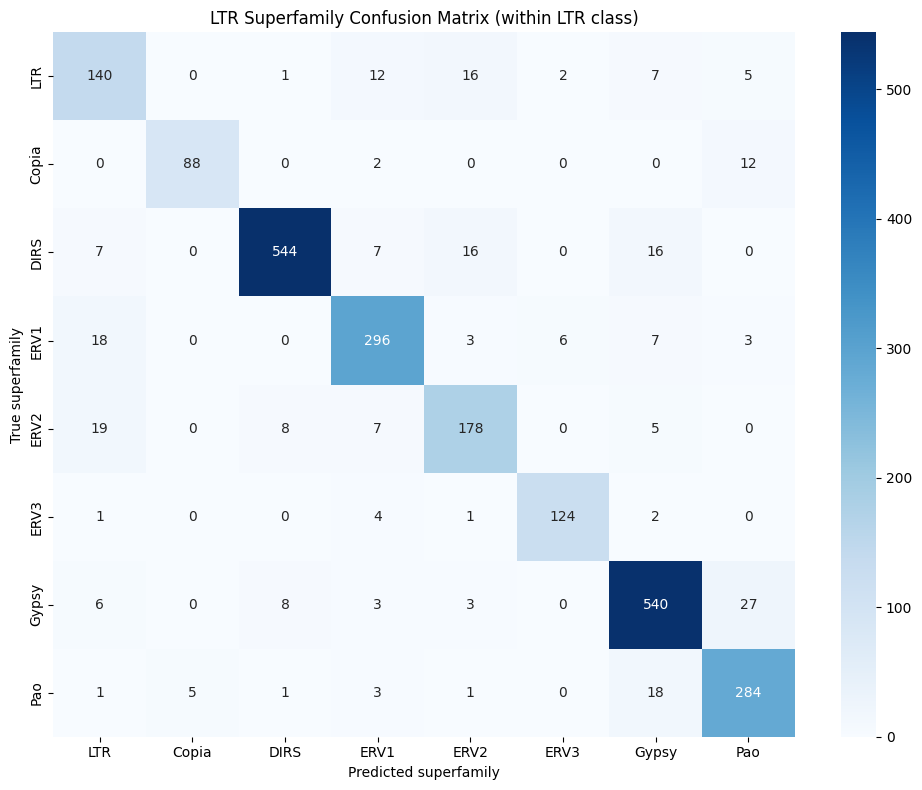

In [9]:
# ── LTR superfamily confusion matrix (within-class) ──────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

ltr_sfs = sorted([s for s in sf_names if s.startswith("LTR")])
ltr_sf_ids = {s: i for i, s in enumerate(sf_names) if s.startswith("LTR")}

# filter to samples whose TRUE class is LTR
ltr_df = df[df["true_class"] == "LTR"].copy()
print(f"LTR test samples: {len(ltr_df)}")
print(f"LTR superfamily error rate: {(~ltr_df['sf_correct']).sum()}/{len(ltr_df)} "
      f"= {(~ltr_df['sf_correct']).mean():.1%}")
print(f"LTR class error rate (misclassified as DNA/LINE): "
      f"{(~ltr_df['class_correct']).sum()}/{len(ltr_df)} = {(~ltr_df['class_correct']).mean():.1%}\n")

# Build confusion matrix for LTR superfamilies
from sklearn.metrics import confusion_matrix
ltr_cm = confusion_matrix(
    ltr_df["true_superfamily"], ltr_df["pred_superfamily"],
    labels=ltr_sfs,
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(ltr_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[s.replace("LTR/", "") for s in ltr_sfs],
            yticklabels=[s.replace("LTR/", "") for s in ltr_sfs],
            ax=ax)
ax.set_xlabel("Predicted superfamily")
ax.set_ylabel("True superfamily")
ax.set_title("LTR Superfamily Confusion Matrix (within LTR class)")
plt.tight_layout()
plt.show()

In [10]:
# ── Per-superfamily error rates + top confusion partners ─────────────────────
rows = []
for sf in ltr_sfs:
    sf_sub = ltr_df[ltr_df["true_superfamily"] == sf]
    n = len(sf_sub)
    if n == 0:
        continue
    n_sf_err = (~sf_sub["sf_correct"]).sum()
    n_cls_err = (~sf_sub["class_correct"]).sum()

    # top confusion targets
    wrong = sf_sub[~sf_sub["sf_correct"]]
    top_targets = wrong["pred_superfamily"].value_counts().head(3)
    top_str = "; ".join(f"{t} ({c})" for t, c in top_targets.items())

    rows.append({
        "superfamily": sf,
        "n_test": n,
        "sf_errors": n_sf_err,
        "sf_error_rate": n_sf_err / n,
        "class_errors": n_cls_err,
        "class_error_rate": n_cls_err / n,
        "top_confusions": top_str,
    })

ltr_err = pd.DataFrame(rows).sort_values("sf_error_rate", ascending=False)
print("LTR superfamily error rates (sorted by SF error rate):\n")
ltr_err

LTR superfamily error rates (sorted by SF error rate):



,superfamily,n_test,sf_errors,sf_error_rate,class_errors,class_error_rate,top_confusions
0,LTR,190,50,0.263158,7,0.036842,LTR/ERV2 (16); LTR/ERV1 (12); LTR/Gypsy (7)
4,LTR/ERV2,222,44,0.198198,5,0.022523,LTR (19); LTR/DIRS (8); LTR/ERV1 (7)
1,LTR/Copia,104,16,0.153846,2,0.019231,LTR/Pao (12); DNA/Academ-1 (2); LTR/ERV1 (2)
3,LTR/ERV1,341,45,0.131965,7,0.020528,LTR (18); LTR/Gypsy (7); LTR/ERV3 (6)
7,LTR/Pao,316,32,0.101266,2,0.006329,LTR/Gypsy (18); LTR/Copia (5); LTR/ERV1 (3)
6,LTR/Gypsy,600,60,0.100000,13,0.021667,LTR/Pao (27); LTR/DIRS (8); LTR (6)
2,LTR/DIRS,600,56,0.093333,8,0.013333,LTR/Gypsy (16); LTR/ERV2 (16); LINE/L1 (7)
5,LTR/ERV3,133,9,0.067669,1,0.007519,LTR/ERV1 (4); LTR/Gypsy (2); LTR (1)


In [11]:
# ── Top LTR bidirectional confusion pairs ────────────────────────────────────
# Merge A→B and B→A into symmetric pairs and rank
from collections import Counter

pair_counts = Counter()
for _, row in ltr_df[~ltr_df["sf_correct"]].iterrows():
    a, b = row["true_superfamily"], row["pred_superfamily"]
    # only count within-LTR confusions
    if not b.startswith("LTR"):
        continue
    pair = tuple(sorted([a, b]))
    pair_counts[pair] += 1

pair_rows = []
for (a, b), count in pair_counts.most_common(15):
    a_to_b = len(ltr_df[(ltr_df["true_superfamily"] == a) & (ltr_df["pred_superfamily"] == b)])
    b_to_a = len(ltr_df[(ltr_df["true_superfamily"] == b) & (ltr_df["pred_superfamily"] == a)])
    pair_rows.append({"pair": f"{a.replace('LTR/','')} ↔ {b.replace('LTR/','')}",
                       "total": count, "A→B": a_to_b, "B→A": b_to_a})

pair_df = pd.DataFrame(pair_rows)
print("Top bidirectional LTR confusion pairs:\n")
pair_df

Top bidirectional LTR confusion pairs:



,pair,total,A→B,B→A
0,Gypsy ↔ Pao,45,27,18
1,LTR ↔ ERV2,35,16,19
2,LTR ↔ ERV1,30,12,18
3,DIRS ↔ ERV2,24,16,8
4,DIRS ↔ Gypsy,24,16,8
5,Copia ↔ Pao,17,12,5
6,LTR ↔ Gypsy,13,7,6
7,ERV1 ↔ ERV2,10,3,7
8,ERV1 ↔ ERV3,10,6,4
9,ERV1 ↔ Gypsy,10,7,3


Top 10 genomes by LTR SF errors:
genome_id  n_total  n_sf_wrong  sf_error_rate
  fAstMex       21           8       0.380952
  aRanTem       36           8       0.222222
  aPelLes       43           7       0.162791
  rAnoSag       13           5       0.384615
  fPorCra       17           5       0.294118
  aManAur       28           5       0.178571
  fEleAnt        8           4       0.500000
  aPleWal       50           4       0.080000
  fNanAch       11           4       0.363636
  aMixFle       38           4       0.105263


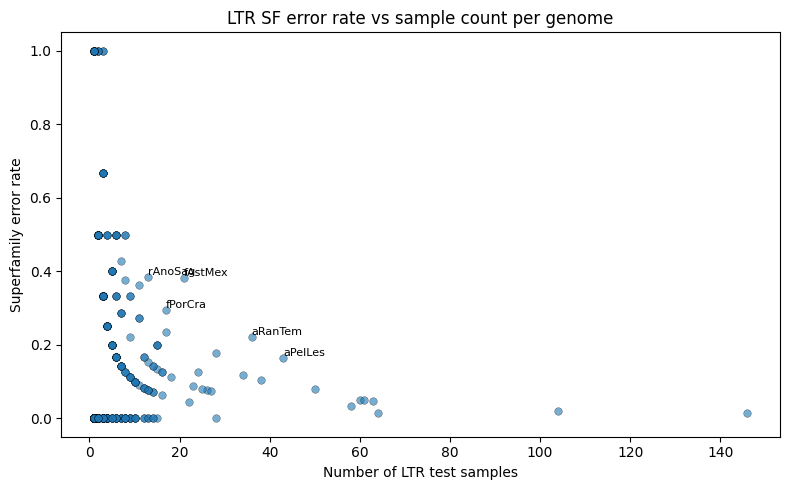

In [12]:
# ── LTR error rate by genome (scatter) ────────────────────────────────────────
ltr_genome = ltr_df.groupby("genome_id").agg(
    n_total=("sf_correct", "size"),
    n_sf_wrong=("sf_correct", lambda x: (~x).sum()),
).reset_index()
ltr_genome["sf_error_rate"] = ltr_genome["n_sf_wrong"] / ltr_genome["n_total"]
ltr_genome = ltr_genome.sort_values("n_sf_wrong", ascending=False)

print("Top 10 genomes by LTR SF errors:")
print(ltr_genome.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(ltr_genome["n_total"], ltr_genome["sf_error_rate"],
           alpha=0.6, s=30, edgecolors="k", linewidths=0.3)
# annotate top-5
for _, r in ltr_genome.head(5).iterrows():
    ax.annotate(r["genome_id"], (r["n_total"], r["sf_error_rate"]),
                fontsize=8, ha="left", va="bottom")
ax.set_xlabel("Number of LTR test samples")
ax.set_ylabel("Superfamily error rate")
ax.set_title("LTR SF error rate vs sample count per genome")
plt.tight_layout()
plt.show()

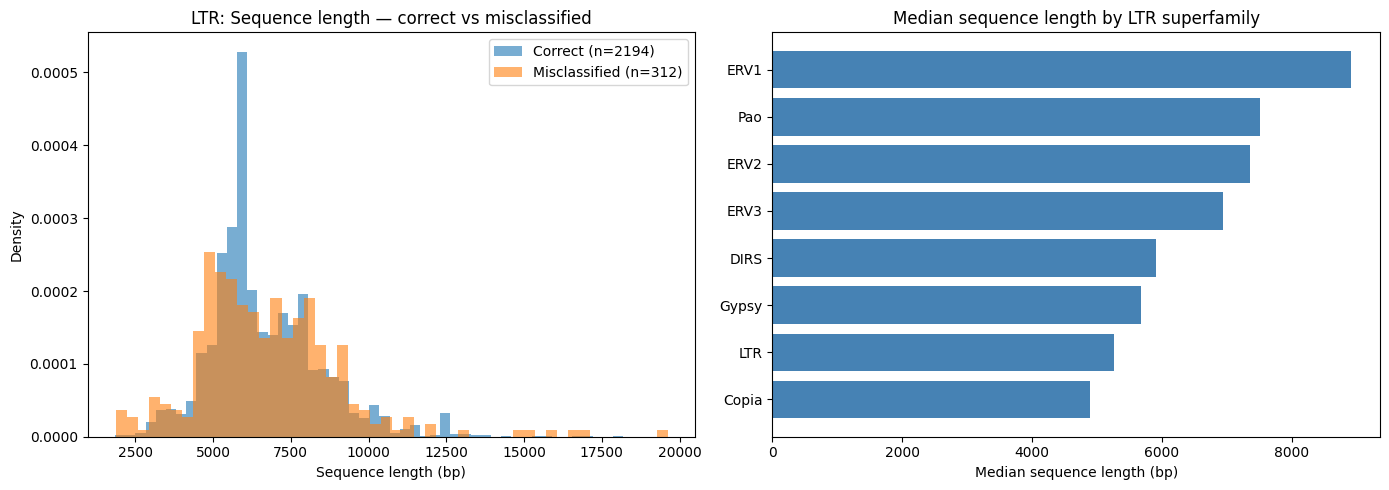

Mann-Whitney U test (correct vs misclassified length): U=342332, p=9.95e-01
Median length — correct: 6142 bp, misclassified: 6442 bp


In [13]:
# ── Sequence length analysis: correct vs misclassified LTR ────────────────────
from Bio import SeqIO

fasta_dict = {}
for rec in SeqIO.parse(str(FASTA_PATH), "fasta"):
    fasta_dict[rec.id] = len(rec.seq)

ltr_df = ltr_df.copy()
ltr_df["seq_len"] = ltr_df["header"].map(fasta_dict)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: length distributions correct vs wrong
correct_lens = ltr_df.loc[ltr_df["sf_correct"], "seq_len"].dropna()
wrong_lens = ltr_df.loc[~ltr_df["sf_correct"], "seq_len"].dropna()
axes[0].hist(correct_lens, bins=50, alpha=0.6, label=f"Correct (n={len(correct_lens)})", density=True)
axes[0].hist(wrong_lens, bins=50, alpha=0.6, label=f"Misclassified (n={len(wrong_lens)})", density=True)
axes[0].set_xlabel("Sequence length (bp)")
axes[0].set_ylabel("Density")
axes[0].set_title("LTR: Sequence length — correct vs misclassified")
axes[0].legend()

# Panel 2: per-superfamily median length
sf_len = ltr_df.groupby("true_superfamily")["seq_len"].agg(["median", "mean", "count"]).reset_index()
sf_len = sf_len.sort_values("median")
axes[1].barh(sf_len["true_superfamily"].str.replace("LTR/", ""), sf_len["median"], color="steelblue")
axes[1].set_xlabel("Median sequence length (bp)")
axes[1].set_title("Median sequence length by LTR superfamily")
plt.tight_layout()
plt.show()

from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(correct_lens, wrong_lens, alternative="two-sided")
print(f"Mann-Whitney U test (correct vs misclassified length): U={stat:.0f}, p={p:.2e}")
print(f"Median length — correct: {correct_lens.median():.0f} bp, misclassified: {wrong_lens.median():.0f} bp")

In [14]:
# ── Biological interpretation of top LTR confusion pairs ──────────────────────

explanations = {
    "Gypsy ↔ Pao": (
        "Gypsy and Pao/BEL are sister clades of metazoan LTR retrotransposons that share "
        "the same domain architecture (gag–pol with INT-CHD) and very similar LTR structures. "
        "Their RT/RNaseH domains are closely related phylogenetically, so k-mer composition "
        "and local motif patterns overlap substantially. Pao elements in non-model vertebrates "
        "may also be annotated inconsistently with Gypsy."
    ),
    "Gypsy ↔ DIRS": (
        "DIRS elements use a tyrosine recombinase (YR) instead of DDE-integrase, but their "
        "internal ORFs (RT, RNaseH) are homologous to Gypsy. In fragmented or short consensus "
        "sequences, the YR domain may be truncated/absent, leaving only the RT region which is "
        "Gypsy-like. DIRS elements can also have split or inverted terminal repeats that look "
        "similar to Gypsy LTRs at the k-mer level."
    ),
    "ERV2 ↔ LTR (unclassified)": (
        "Generic 'LTR' entries are elements whose superfamily could not be assigned by the "
        "original RepeatMasker/RepBase annotation — they typically lack diagnostic domains or "
        "have diverged beyond recognition. Many are likely degraded ERVs. ERV2 elements "
        "(betaretrovirus-like) confused with 'LTR' suggests degenerate ERV2 copies whose "
        "diagnostic pro–pol domain structure has decayed through mutation."
    ),
    "ERV1 ↔ LTR (unclassified)": (
        "Same mechanism as ERV2↔LTR: ancient/degenerate ERV1 (gammaretrovirus-like) copies "
        "lose env and internal coding capacity, leaving only LTR-flanked non-coding sequence "
        "that the model cannot distinguish from generic LTR. ERV1 and ERV2 also share PBS "
        "(primer binding site) motifs that overlap with the 'LTR' catch-all."
    ),
    "DIRS ↔ ERV2": (
        "Both have comparable element lengths (5–10 kb) and AT-rich internal regions. "
        "DIRS and ERV2 share RT/RNaseH domain homology; when the discriminating domains "
        "(YR for DIRS, env for ERV2) are absent or truncated in the consensus, the remaining "
        "k-mer composition of the coding regions is very similar."
    ),
    "LTR ↔ ERV1/ERV2": (
        "The generic 'LTR' category is a catch-all for elements lacking clear superfamily "
        "assignment. The model predicts a specific superfamily (ERV1 or ERV2) for these, "
        "which may actually represent correct reclassification of previously unresolved elements."
    ),
    "Copia ↔ Pao": (
        "Copia elements have a distinctive gag–pol domain order (INT before RT) compared to "
        "other LTR retrotransposons, but at the k-mer and motif level, short/fragmented Copia "
        "consensus sequences can overlap with Pao. Both are relatively rare in vertebrates, "
        "leading to limited training data and weaker learned discriminative features."
    ),
    "ERV1 ↔ ERV3": (
        "ERV1 (gamma-like) and ERV3 (spuma-like) share the same basic LTR-gag-pol-env "
        "architecture. ERV3 elements in vertebrates are often highly degraded, and the "
        "remaining diagnostic features overlap with ERV1, particularly in PBS and PPT motifs. "
        "The two classes have fuzzy boundaries even in curated databases."
    ),
}

print("=" * 80)
print("BIOLOGICAL INTERPRETATION OF TOP LTR CONFUSION PAIRS")
print("=" * 80)

# Print in order of confusion count
for _, row in pair_df.iterrows():
    pair_name = row["pair"]
    count = row["total"]
    # try to match with explanations
    matched = None
    for key in explanations:
        # match by checking if the pair components appear in the key
        parts = pair_name.split(" ↔ ")
        key_parts = key.split(" ↔ ")
        if set(parts) == set(key_parts):
            matched = key
            break
        # also try matching with "LTR" -> cleaned names
        clean_parts = [p.replace("LTR/", "").strip() for p in parts]
        # handle "(unclassified)" for bare "LTR"
        clean_parts_alt = ["LTR (unclassified)" if p == "LTR" else p for p in clean_parts]
        if set(clean_parts) == set(key_parts) or set(clean_parts_alt) == set(key_parts):
            matched = key
            break
    
    if matched:
        print(f"\n{'─' * 80}")
        print(f"  {pair_name}  (n={count}, {row['A→B']}↔{row['B→A']})")
        print(f"{'─' * 80}")
        print(f"  {explanations[matched]}")

# Print any remaining explanations not matched
matched_keys = set()
for _, row in pair_df.iterrows():
    pair_name = row["pair"]
    parts = pair_name.split(" ↔ ")
    for key in explanations:
        key_parts = key.split(" ↔ ")
        clean_parts = [p.replace("LTR/", "").strip() for p in parts]
        clean_parts_alt = ["LTR (unclassified)" if p == "LTR" else p for p in clean_parts]
        if set(parts) == set(key_parts) or set(clean_parts) == set(key_parts) or set(clean_parts_alt) == set(key_parts):
            matched_keys.add(key)

for key in explanations:
    if key not in matched_keys:
        print(f"\n{'─' * 80}")
        print(f"  {key}")
        print(f"{'─' * 80}")
        print(f"  {explanations[key]}")

BIOLOGICAL INTERPRETATION OF TOP LTR CONFUSION PAIRS

────────────────────────────────────────────────────────────────────────────────
  Gypsy ↔ Pao  (n=45, 27↔18)
────────────────────────────────────────────────────────────────────────────────
  Gypsy and Pao/BEL are sister clades of metazoan LTR retrotransposons that share the same domain architecture (gag–pol with INT-CHD) and very similar LTR structures. Their RT/RNaseH domains are closely related phylogenetically, so k-mer composition and local motif patterns overlap substantially. Pao elements in non-model vertebrates may also be annotated inconsistently with Gypsy.

────────────────────────────────────────────────────────────────────────────────
  LTR ↔ ERV2  (n=35, 16↔19)
────────────────────────────────────────────────────────────────────────────────
  Generic 'LTR' entries are elements whose superfamily could not be assigned by the original RepeatMasker/RepBase annotation — they typically lack diagnostic domains or have diver

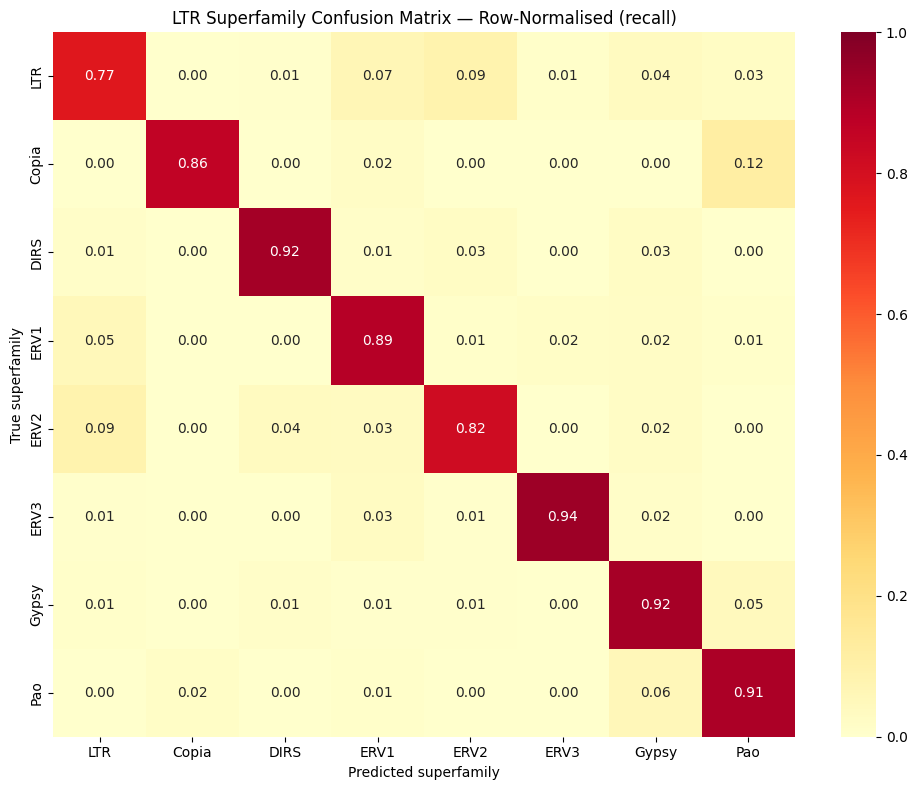


Per-superfamily recall (diagonal of normalised CM):
  LTR                   recall=0.765  (n=183)
  LTR/Copia             recall=0.863  (n=102)
  LTR/DIRS              recall=0.922  (n=590)
  LTR/ERV1              recall=0.889  (n=333)
  LTR/ERV2              recall=0.820  (n=217)
  LTR/ERV3              recall=0.939  (n=132)
  LTR/Gypsy             recall=0.920  (n=587)
  LTR/Pao               recall=0.907  (n=313)


In [15]:
# ── Normalised confusion matrix (row-normalised) ─────────────────────────────
ltr_cm_norm = ltr_cm.astype(float)
row_sums = ltr_cm_norm.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1  # avoid division by zero
ltr_cm_norm = ltr_cm_norm / row_sums

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(ltr_cm_norm, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=[s.replace("LTR/", "") for s in ltr_sfs],
            yticklabels=[s.replace("LTR/", "") for s in ltr_sfs],
            vmin=0, vmax=1, ax=ax)
ax.set_xlabel("Predicted superfamily")
ax.set_ylabel("True superfamily")
ax.set_title("LTR Superfamily Confusion Matrix — Row-Normalised (recall)")
plt.tight_layout()
plt.show()

# Summary table: recall per LTR superfamily
print("\nPer-superfamily recall (diagonal of normalised CM):")
for i, sf in enumerate(ltr_sfs):
    recall = ltr_cm_norm[i, i]
    n = ltr_cm[i].sum()
    print(f"  {sf:20s}  recall={recall:.3f}  (n={n})")